In [37]:
import re

def query_to_tag(query: str) -> str:
    parts = re.findall(r'(\w+)\s*==\s*([\w.]+)', query)
    if not parts:
        return ""

    key_map = {
        "s": "xi",
        "burstiness": "b",
    }

    out = []
    for k, v in parts:
        out.append(f"{key_map.get(k, k)}={v}")

    return "_".join(out)


In [38]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D

In [ ]:
mpl.rcdefaults()


#* BIGGER SIZE
plt.rcParams.update({"text.usetex": True})
plt.rcParams["font.family"] = 'STIXGeneral'
plt.rc('font', size=22)          # controls default text sizes
plt.rc('axes', titlesize=14)     # fontsize of the axes title
plt.rc('axes', labelsize=22)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=22)    # fontsize of the tick labels
plt.rc('ytick', labelsize=22)    # fontsize of the tick labels
plt.rc('legend', fontsize=22)    # legend fontsize
plt.rc('figure', titlesize=14)   # fontsize of the figure title


In [40]:
from pathlib import Path

In [41]:
BATCH = "008"
# Use .expanduser() to turn "~" into "/home/yourusername"
PARQUETS = Path("~/tesi/sarafu/final_simulations").expanduser()
PICKLED = Path("~/papers/adtxns_paper/pickled_data").expanduser()
SARAFU_PICKLED = PICKLED / "sarafu"

FIGURES = Path("~/papers/adtxns_paper/figures/histograms").expanduser()


In [43]:
sarafu = pickle.load(open(SARAFU_PICKLED / "sarafu.pkl", "rb"))

In [42]:
metadata = pickle.load(open(PICKLED / BATCH / "metadata.pkl", "rb"))


SINGLE SIMULATION (SELECT COUPLE s and burstiness)

In [33]:
burstiness = 0.25
spending_noise = 5
QUERY = f"s == {spending_noise} and burstiness == {burstiness}"

In [34]:
simu_id = metadata.query(QUERY).iloc[0].simulation_id
meta_row = metadata.query(QUERY).iloc[0]

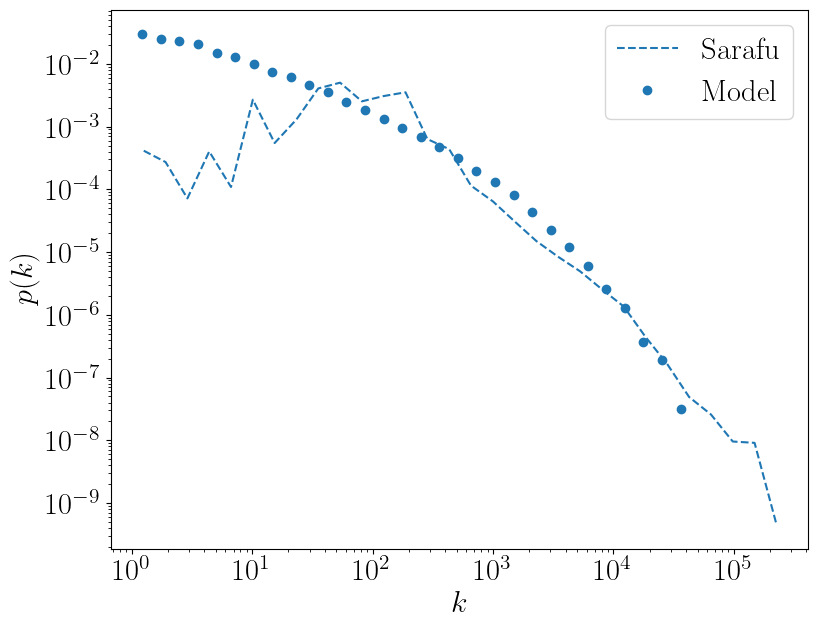

In [35]:
keyword = "final_balances"
disp = "single"


# filenames (standard)
fname_sarafu = f"sarafu__metric={keyword}__s=NA__b=NA"
fname_simu   = f"simulation__metric={keyword}__s={spending_noise}__b={burstiness}"

# load
h1 = pickle.load(open(SARAFU_PICKLED / "histograms" / f"{fname_sarafu}.pkl", "rb"))
h2 = pickle.load(open(PICKLED / BATCH / "histograms" / f"{fname_simu}.pkl", "rb"))

# plot
fig, ax = plt.subplots(1, 1, figsize=(9, 7))

ax.plot(h1[0], h1[1], "--", label="Sarafu", color="tab:blue")
ax.plot(h2[0], h2[1], "o",  label=rf"Model",  color="tab:blue")

ax.set_xlabel("$k$")
ax.set_ylabel("$p(k)$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()

# save figure with same stem
# fig.savefig(FIGURES / f"{fname_simu}.pdf")


fig.savefig(
    FIGURES / f"{disp}__metrics={keyword}__s={spending_noise}__b={burstiness}.pdf"
)

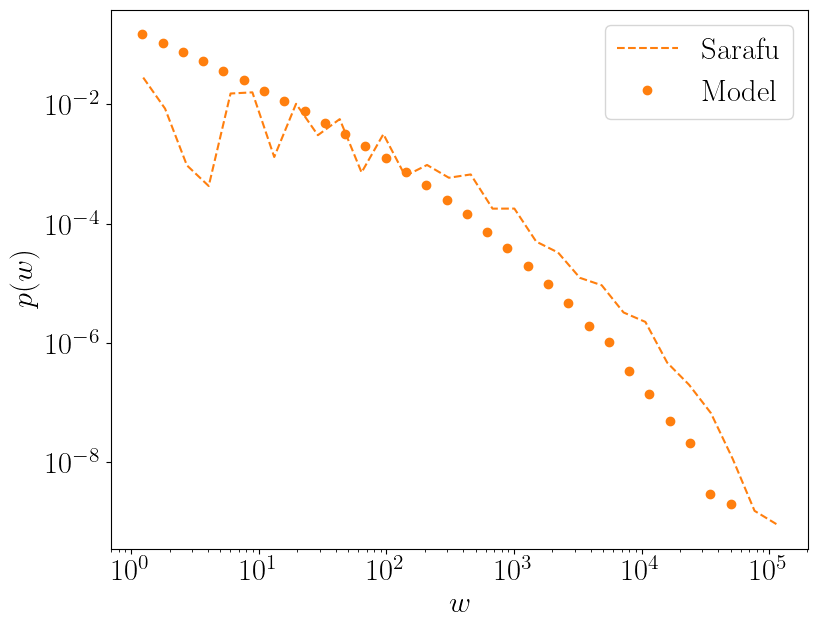

In [36]:
keyword = "transaction_size"
disp = "single"


# filenames (standard)
fname_sarafu = f"sarafu__metric={keyword}__s=NA__b=NA"
fname_simu   = f"simulation__metric={keyword}__s={spending_noise}__b={burstiness}"

# load
h1 = pickle.load(open(SARAFU_PICKLED / "histograms" / f"{fname_sarafu}.pkl", "rb"))
h2 = pickle.load(open(PICKLED / BATCH / "histograms" / f"{fname_simu}.pkl", "rb"))

# plot
fig, ax = plt.subplots(1, 1, figsize=(9, 7))

ax.plot(h1[0], h1[1], "--", label="Sarafu", color="tab:orange")
ax.plot(h2[0], h2[1], "o",  label=rf"Model", color="tab:orange")

ax.set_xlabel("$w$")
ax.set_ylabel("$p(w)$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()

fig.savefig(
    FIGURES / f"{disp}__metrics={keyword}__s={spending_noise}__b={burstiness}.pdf"
)


In [37]:
# keyword1 = "transaction_size"
# keyword2 = "final_balances"

# disp = 'column'


# # filenames (standard)
# fname_ts_sarafu = f"sarafu__metric={keyword1}__s=NA__b=NA"
# fname_ts_simu   = f"simulation__metric={keyword1}__s={spending_noise}__b={burstiness}"

# fname_fb_sarafu = f"sarafu__metric={keyword2}__s=NA__b=NA"
# fname_fb_simu   = f"simulation__metric={keyword2}__s={spending_noise}__b={burstiness}"

# # load histograms
# h1_ts = pickle.load(open(SARAFU_PICKLED / "histograms" / f"{fname_ts_sarafu}.pkl", "rb"))
# h2_ts = pickle.load(open(PICKLED / BATCH / "histograms" / f"{fname_ts_simu}.pkl", "rb"))

# h1_fb = pickle.load(open(SARAFU_PICKLED / "histograms" / f"{fname_fb_sarafu}.pkl", "rb"))
# h2_fb = pickle.load(open(PICKLED / BATCH / "histograms" / f"{fname_fb_simu}.pkl", "rb"))

# # plot
# fig, ax = plt.subplots(2, 1, figsize=(9, 14))

# # --- transaction size ---
# ax[0].plot(h1_ts[0], h1_ts[1], "--", color="tab:orange", 
# # label="sarafu"
# )
# ax[0].plot(h2_ts[0], h2_ts[1], "o",  color="tab:orange", 
# # label=rf"$\xi={s}, b={b}$"
# )
# ax[0].set_xlabel("$w$")
# ax[0].set_ylabel("$p(w)$")
# ax[0].set_xscale("log")
# ax[0].set_yscale("log")
# ax[0].legend()

# # --- final balances ---
# ax[1].plot(h1_fb[0],
#             h1_fb[1],
#             "--",
#             color="tab:blue",
#             # label="sarafu"
#             )
# ax[1].plot(h2_fb[0], 
#             h2_fb[1], "o",  color="tab:blue", 
#             # label=rf"$\xi={s}, b={b}$"
#             )
# ax[1].set_xlabel("$k$")
# ax[1].set_ylabel("$p(k)$")
# ax[1].set_xscale("log")
# ax[1].set_yscale("log")
# ax[1].legend()

# # panel labels
# ax[0].text(0.02, 0.05, "(a)", transform=ax[0].transAxes, fontsize=14)
# ax[1].text(0.02, 0.05, "(b)", transform=ax[1].transAxes, fontsize=14)

# label_model=rf"Model"

# # custom legend
# legend_elements = [
#     Line2D([0], [0], linestyle="--", color="black", label="Sarafu"),
#     Line2D([0], [0], linestyle="None", marker="o", color="black",
#            label=label_model),
#     # Line2D([0], [0], linestyle="-", color="C0", label="Final Balances"),
#     # Line2D([0], [0], linestyle="-", color="C1", label="Transaction Sizes"),
# ]

# ax.legend(handles=legend_elements)

# fig.tight_layout()

# # save figure with metadata encoded
# fig.savefig(
#     FIGURES / f"{disp}__metrics={keyword}__s={spending_noise}__b={burstiness}.pdf"
# )


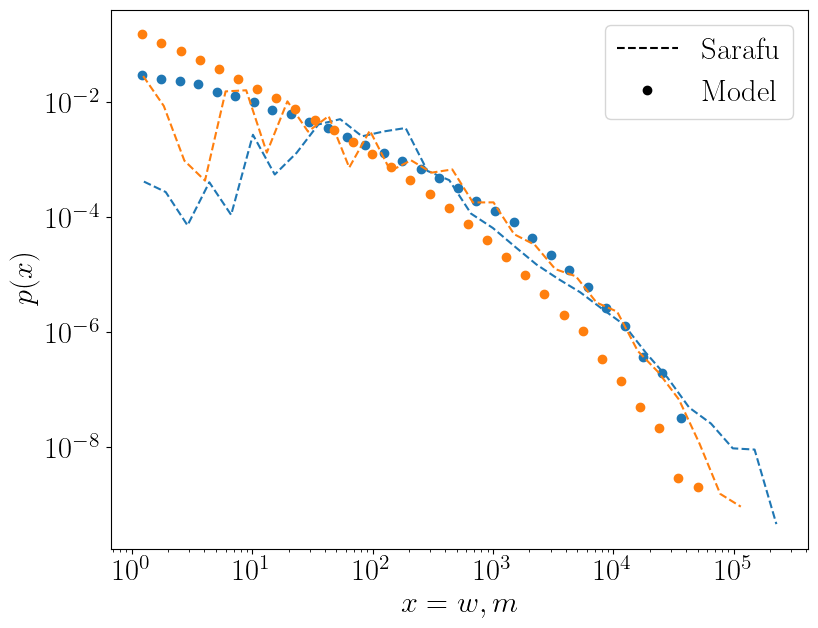

In [38]:
# keywords
kw_fb = "final_balances"
kw_ts = "transaction_size"

disp = 'overlap'

keyword = kw_fb + "+"+ kw_ts

# filenames (standard)
fname_fb_sarafu = f"sarafu__metric={kw_fb}__s=NA__b=NA"
fname_fb_simu   = f"simulation__metric={kw_fb}__s={spending_noise}__b={burstiness}"

fname_ts_sarafu = f"sarafu__metric={kw_ts}__s=NA__b=NA"
fname_ts_simu   = f"simulation__metric={kw_ts}__s={spending_noise}__b={burstiness}"

# load histograms
h1 = pickle.load(open(SARAFU_PICKLED / "histograms" / f"{fname_fb_sarafu}.pkl", "rb"))
h2 = pickle.load(open(PICKLED / BATCH / "histograms" / f"{fname_fb_simu}.pkl", "rb"))

h3 = pickle.load(open(SARAFU_PICKLED / "histograms" / f"{fname_ts_sarafu}.pkl", "rb"))
h4 = pickle.load(open(PICKLED / BATCH / "histograms" / f"{fname_ts_simu}.pkl", "rb"))

# plot
fig, ax = plt.subplots(1, 1, figsize=(9, 7))

ax.plot(h1[0], h1[1], "--", color="tab:blue")
ax.plot(h2[0], h2[1], "o",  color="tab:blue")

ax.plot(h3[0], h3[1], "--", color="tab:orange")
ax.plot(h4[0], h4[1], "o",  color="tab:orange")

ax.set_xlabel("$x = w, m$")
ax.set_ylabel("$p(x)$")
ax.set_xscale("log")
ax.set_yscale("log")

# label_model=rf"Model: $\xi={s}, b={b}$"
label_model=rf"Model"

# custom legend
legend_elements = [
    Line2D([0], [0], linestyle="--", color="black", label="Sarafu"),
    Line2D([0], [0], linestyle="None", marker="o", color="black",
           label=label_model),
    # Line2D([0], [0], linestyle="-", color="C0", label="Final Balances"),
    # Line2D([0], [0], linestyle="-", color="C1", label="Transaction Sizes"),
]

ax.legend(handles=legend_elements)

# save
fig.savefig(
    FIGURES / f"{disp}__metrics={keyword}__s={spending_noise}__b={burstiness}.pdf"
)

VARYING THE SIMULATION (SELECT JUST burstiness or s)

In [212]:
QUERY = f"burstiness == {burstiness}"
meta_slice = metadata.query(QUERY)
meta_slice = meta_slice.query("s not in [20,100]")
tag=query_to_tag(QUERY)


# meta_slice

In [213]:
tag

'b=0.75'

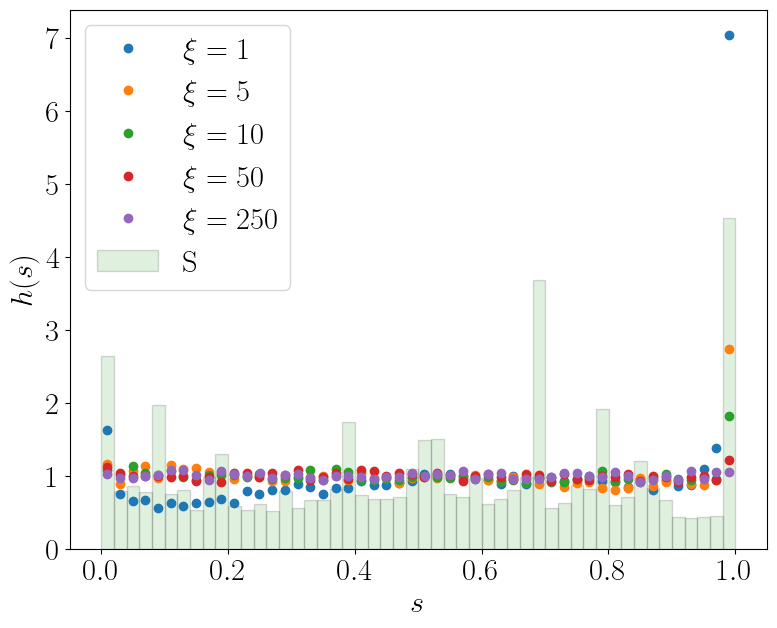

In [214]:

keyword = "spending_parameters"

# ---- load sarafu (bar base) ----
fname_sarafu = f"sarafu__metric={keyword}__s=NA__b=NA"
h1 = pickle.load(open(SARAFU_PICKLED / "histograms" / f"{fname_sarafu}.pkl", "rb"))

fig, ax = plt.subplots(1, 1, figsize=(9, 7))

# sarafu as bars (expects h1 = (centers, heights, widths))
ax.bar(h1[0], h1[1], h1[2], align="center", edgecolor="k", alpha=0.15, color="tab:green", label="S")

# ---- overlay simulations (subset selected by QUERY) ----
for _, row in meta_slice.iterrows():
    s = row["s"]
    b = row["burstiness"]

    fname_simu = f"simulation__metric={keyword}__s={s}__b={b}"
    h_simu = pickle.load(open(PICKLED / BATCH / "histograms" / f"{fname_simu}.pkl", "rb"))

    # simulation as line (expects h_simu = (x, y) or (centers, heights, ...))
    ax.plot(h_simu[0], h_simu[1], 'o',linestyle="None", label=rf"$\xi={s}$")

ax.set_xlabel(r"$s$")
ax.set_ylabel(r"$h(s)$")
ax.legend()

# optional save (encodes the filter used + metric)
fig.savefig(FIGURES / f"comparison__metric={keyword}__filter={tag}.pdf")


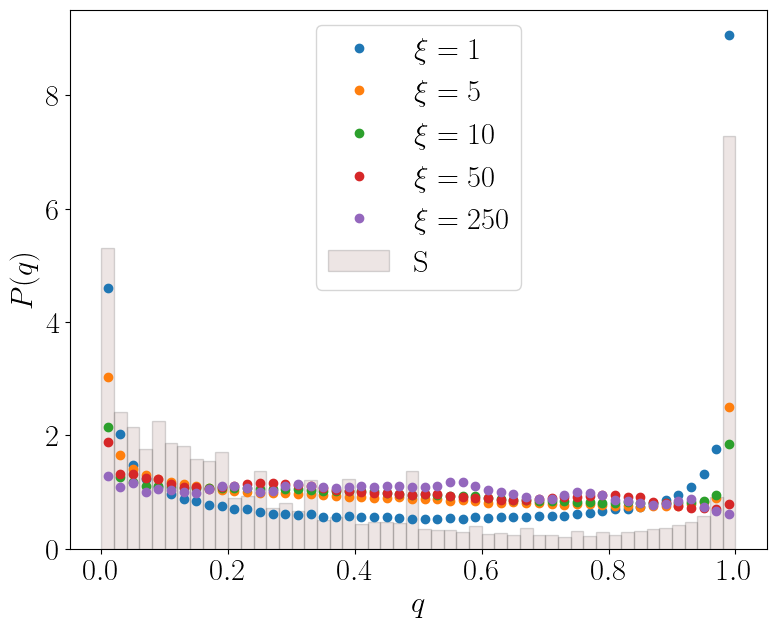

In [215]:

keyword = "spending_fraction"

# ---- load sarafu (bar base) ----
fname_sarafu = f"sarafu__metric={keyword}__s=NA__b=NA"
h1 = pickle.load(open(SARAFU_PICKLED / "histograms" / f"{fname_sarafu}.pkl", "rb"))

fig, ax = plt.subplots(1, 1, figsize=(9, 7))

# sarafu as bars (expects h1 = (centers, heights, widths))
ax.bar(h1[0], h1[1], h1[2], align="center", edgecolor="k", alpha=0.15, color="tab:brown", label="S")

# ---- overlay simulations (subset selected by QUERY) ----
for _, row in meta_slice.iterrows():
    s = row["s"]
    b = row["burstiness"]

    fname_simu = f"simulation__metric={keyword}__s={s}__b={b}"
    h_simu = pickle.load(open(PICKLED / BATCH / "histograms" / f"{fname_simu}.pkl", "rb"))

    # simulation as line (expects h_simu = (x, y) or (centers, heights, ...))
    ax.plot(h_simu[0], h_simu[1], 'o',linestyle="None", label=rf"$\xi={s}$")

ax.set_xlabel(r"$q$")
ax.set_ylabel(r"$P(q)$")

ax.legend()

# optional save (encodes the filter used + metric)
fig.savefig(FIGURES / f"comparison__metric={keyword}__filter={tag}.pdf")


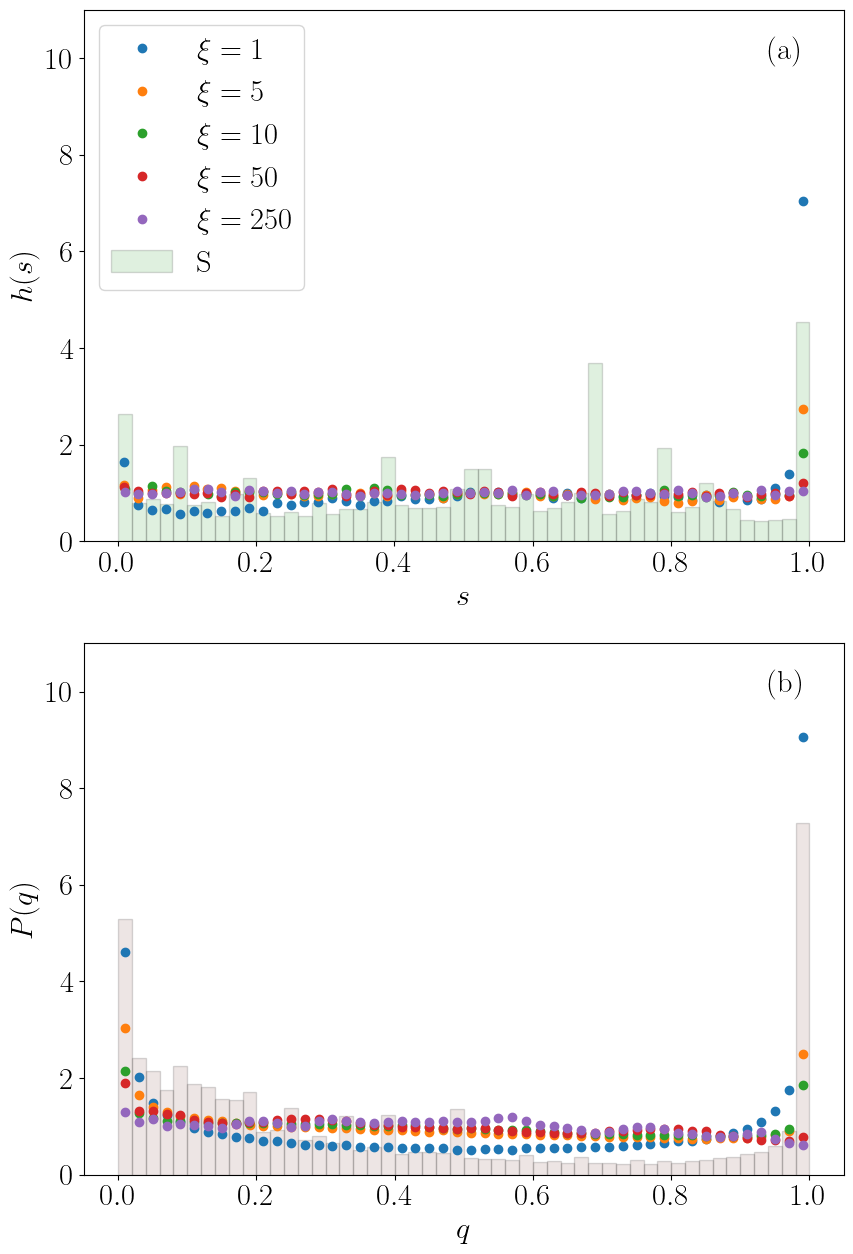

In [30]:
R,C = 2,1
W = 9
H = 6.5


fig, ax = plt.subplots(2, 1, figsize=(W*C,H*R), sharex=False)

# =======================
# (a) spending_parameters
# =======================
keyword1 = "spending_parameters"
disp = 'column'
x_text = 0.9
y_text = 0.95

fname_sarafu = f"sarafu__metric={keyword1}__s=NA__b=NA"
h1 = pickle.load(open(SARAFU_PICKLED / "histograms" / f"{fname_sarafu}.pkl", "rb"))

ax[0].bar(
    h1[0], h1[1], h1[2],
    align="center", edgecolor="k",
    alpha=0.15, color="tab:green",
    label="S"
)

for _, row in meta_slice.iterrows():
    s = row["s"]
    b = row["burstiness"]

    fname_simu = f"simulation__metric={keyword1}__s={s}__b={b}"
    h_simu = pickle.load(open(PICKLED / BATCH / "histograms" / f"{fname_simu}.pkl", "rb"))

    ax[0].plot(h_simu[0], h_simu[1], "o", linestyle="None", label=rf"$\xi={s}$")


ax[0].set_ylabel(r"$h(s)$")
ax[0].set_xlabel(r"$s$")
ax[0].legend()
ax[0].text(x_text, y_text, "(a)", transform=ax[0].transAxes, va="top")


# ===================
# (b) spending_fraction
# ===================
keyword2 = "spending_fraction"

fname_sarafu = f"sarafu__metric={keyword2}__s=NA__b=NA"
h1 = pickle.load(open(SARAFU_PICKLED / "histograms" / f"{fname_sarafu}.pkl", "rb"))

ax[1].bar(
    h1[0], h1[1], h1[2],
    align="center", edgecolor="k",
    alpha=0.15, color="tab:brown",
    label="sarafu"
)

for _, row in meta_slice.iterrows():
    s = row["s"]
    b = row["burstiness"]

    fname_simu = f"simulation__metric={keyword2}__s={s}__b={b}"
    h_simu = pickle.load(open(PICKLED / BATCH / "histograms" / f"{fname_simu}.pkl", "rb"))

    ax[1].plot(h_simu[0], h_simu[1], "o", linestyle="None", label=rf"$\xi={s}$")

ax[1].set_xlabel(r"$q$")
ax[1].set_ylabel(r"$P(q)$")
# ax[1].legend()
ax[1].text(x_text, y_text, "(b)", transform=ax[1].transAxes, va="top")


for ax_ in ax:
    ax_.set_ylim(0, 11)
    # ax_.set_aspect("equal")

fig.tight_layout()
fig.savefig(
    FIGURES / f"{disp}__metrics={keyword1}+{keyword2}__filter={tag}.pdf"
)


In [34]:
metric = f"inter_event_times"
spec1 = 'individual'
spec2 = 'global'
fname1 = f"sarafu__metric={metric}_{spec1}__s=NA__b=NA.pkl"
fname2 = f"sarafu__metric={metric}_{spec2}__s=NA__b=NA.pkl"

hs = pickle.load(open(SARAFU_PICKLED / "histograms" / fname1, "rb"))
h0 = pickle.load(open(SARAFU_PICKLED / "histograms" / fname2, "rb"))

[]

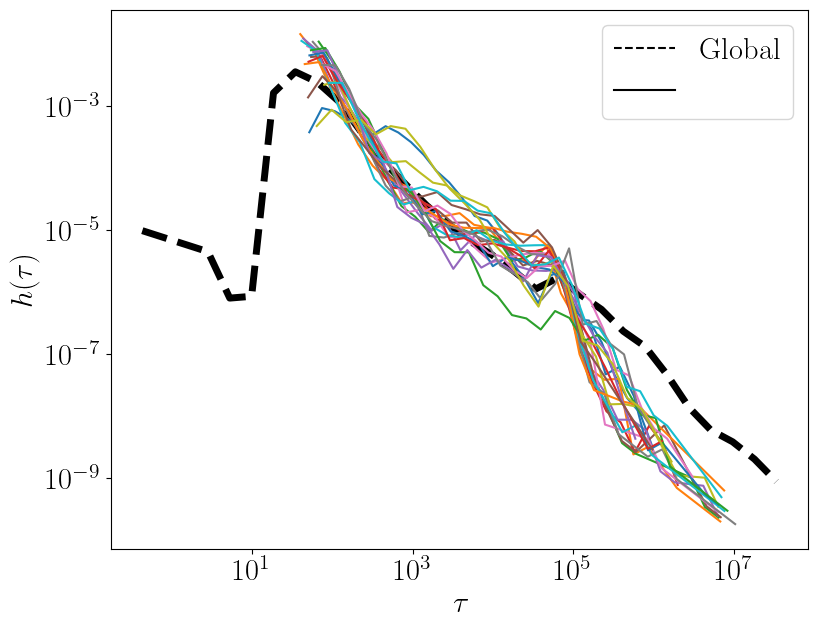

In [ ]:
R,C = 1,1
W = 9
H = 7


fig, ax = plt.subplots(R,C, figsize=(W*C,H*R), sharex=False)


keyword = "inter-event_times"
disp = 'single'
tag = "sarafu-global-vs-single"
x_text = 0.9
y_text = 0.95

ax.plot(h0[0], h0[1], "--", color="k",lw = 5)


most_active_sarafu = sarafu['agents'].nlargest(50, columns = 'tx_out')[['crid','tx_out']]

for k in most_active_sarafu.head(20).crid:
    h = hs[k]
    ax.plot(h[0],h[1])

ax.set_ylabel(r"$h(\tau)$")
ax.set_xlabel(r"$\tau$")

legend_elements = [
    Line2D([0], [0], linestyle="--", color="black", label="Global"),
    Line2D([0], [0], linestyle="-", marker=None, color="black",
           label="Individuals"),
    # Line2D([0], [0], linestyle="-", color="C0", label="Final Balances"),
    # Line2D([0], [0], linestyle="-", color="C1", label="Transaction Sizes"),
]
ax.legend(handles=legend_elements)
ax.loglog()
# ax.text(x_text, y_text, "(a)", transform=ax.transAxes, va="top")

# fig.tight_layout()


In [51]:
fig.savefig(
    FIGURES / f"{disp}__metrics={keyword}__filter={tag}.pdf"
)

In [ ]:
txns_floor = 0
bal_floor = 0

txdf = TXDF.copy(deep=True) #always do this
txdf['period'] = pd.cut(txdf.date, bins=NUM_PERIODS, labels=False) 


disb_df = txdf[disbursement(txdf)]
out_df = txdf[withdrawal(txdf)]
std_df = txdf[standard(txdf)]

bal_pre, bal_post = balance_constructor(txdf,USERS)
bal_df = bal_post.loc[(~bal_post.role.isin(['ADMIN','TOKEN_AGENT']))]
bal_pivot = pd.pivot_table(bal_df, index='crid',columns='period', values='balance', aggfunc='last')
bal_pivot = bal_pivot.ffill(axis=1)

disb_list = [disb_df.loc[txdf.period==i]['weight'] for i in disb_df['period'].unique()]
out_list = [out_df.loc[txdf.period==i]['weight'] for i in out_df['period'].unique()]
std_list = [std_df.loc[txdf.period==i]['weight'] for i in std_df['period'].unique()]

bal_list = [bal_pivot[col].values for col in bal_pivot.columns]



disb_sum = np.array([np.sum(np.where(~np.isnan(sample),sample,0)) for sample in disb_list])
out_sum = np.array([np.sum(np.where(~np.isnan(sample),sample,0)) for sample in out_list])
std_sum = np.array([np.sum(np.where(~np.isnan(sample),sample,0)) for sample in std_list])
bal_sum = np.array([np.sum(np.where(~np.isnan(sample),sample,0)) for sample in bal_list])
bal_sum_0 = bal_pre.loc[(~bal_pre.role.isin(['ADMIN','TOKEN_AGENT']))].groupby('crid').balance.first().sum()
net = bal_sum_0 + disb_sum - out_sum 
population = bal_pivot.count()
total_activity = std_df.groupby('period').weight.count()
calc_bal_sum = disb_sum - out_sum

period_to_date = txdf.groupby('period')['date'].min()  # Get start date for each period
dates = period_to_date.sort_index().values  # Ensure chronological order


#first plot
fig = plt.figure()
plt.plot(dates,disb_sum,label='total disbursement'.title())
plt.plot(dates,-out_sum, label = 'total reclamation'.title())
plt.plot(dates,std_sum, label = 'total standard'.title())
plt.plot(dates,net, label = 'net balance'.title())
plt.plot(dates,bal_sum, '-.',label = 'total wealth'.title())
plt.axhline(y=0, color='k', linestyle='--')
plt.axhline(y=bal_sum_0, color='k', linestyle='--')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Sarafu",rotation = 0,labelpad=20)
plt.legend()

fig.savefig(f'{fig_path}/flows.png',bbox_inches='tight')

#second plot
fig = plt.figure()
plt.plot(dates,disb_sum/total_activity,label='total disbursement'.title())
plt.plot(dates,-out_sum/total_activity, label = 'total reclamation'.title())
plt.plot(dates,std_sum/total_activity, label = 'total standard'.title())
plt.plot(dates,net/total_activity, label = 'net balance'.title())

plt.axhline(y=0, color='k', linestyle='--')
plt.xticks(rotation=45, ha='right')

plt.ylabel('Sar/Tx')
plt.legend()
fig.savefig(f'{fig_path}/flows-per-tx.png',bbox_inches='tight')


#third plots
fig = plt.figure()
plt.plot(dates,bal_sum/population, '-.',label = 'Sarafu per agent'.title())
plt.axhline(y=np.mean(bal_sum/population), color='r', linestyle='--',label ='time average'.title())
plt.xticks(rotation=45, ha='right')
plt.ylabel('Tx/User')
plt.legend()
fig.savefig(f'{fig_path}/sarafu-per-user.png',bbox_inches='tight')



fig = plt.figure()
plt.plot(dates,scale_vect(population),'r.-', label = 'population'.title())
plt.plot(dates,scale_vect(bal_sum), label = 'sum of balance'.title())
plt.plot(dates,scale_vect(total_activity), '-.',label = 'total activity'.title())
# plt.xlabel()
plt.ylabel('Scaled Values',rotation = 0,labelpad=20)
plt.xticks(rotation=45, ha='right')
plt.legend()
fig.savefig(f'{fig_path}/scaled-sizes.png',bbox_inches='tight')


